In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

In [2]:
# Path to train dataset
train_path = r"C:\Users\arpra\OneDrive\Desktop\naisc\NAISC-Singtel-2026-main\public_data\train.csv"

# Load dataset
train_df = pd.read_csv(train_path)

# Preview dataset
train_df.head()

,CustomerID,UserGender,UserAge,YoungAdultFlag,RetireeStatus,Married,Dependents,NumberofDependents,Country,State,LocationCity,AreaCode,Latitude,Longitude,Population,ReferredaFriend,NumberofReferrals,TenureinMonths,Offer,VoiceService,AvgMonthlyLongDistanceCharges,AdditionalLines,ConnectivityType,InternetType,DataUsageAvg,CyberSecuritySvc,CloudStorageSvc,HardwareInsurance,PrioritySupport,VideoSvc_A,VideoSvc_B,AudioSvc,UnlimitedData,Contract,DigitalInvoicing,TransactionMode,MonthlyCharge,TotalCharges,TotalRefunds,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,CustomerLifetimeValue,ChurnStatus,Month
0,1610a102a7854c5d,Male,71,No,Yes,Yes,Yes,1,United States,California,Pine Valley,91962,32.800671,-116.483363,1604,Yes,9,38,NaN,Yes,28.30,Yes,Yes,Fiber Optic,27,No,Yes,No,No,Yes,Yes,No,Yes,One Year,No,Bank Withdrawal,101.15,3741.85,0.0,0,1075.40,4817.25,4036,No,25-Jan
1,7b4b47a335af4741,Male,77,No,Yes,Yes,No,0,United States,California,Cabazon,92230,33.929812,-116.760580,2355,Yes,5,27,NaN,Yes,33.57,Yes,Yes,DSL,21,No,Yes,Yes,Yes,Yes,Yes,No,Yes,One Year,Yes,Bank Withdrawal,84.80,2309.55,0.0,0,906.39,3215.94,5352,No,25-Jan
2,81465cd8c020404b,Male,78,No,Yes,Yes,No,0,United States,California,Desert Center,92239,33.889605,-115.257009,964,Yes,7,33,NaN,Yes,25.15,Yes,Yes,Fiber Optic,20,Yes,No,Yes,Yes,Yes,Yes,No,Yes,One Year,Yes,Bank Withdrawal,109.90,3694.70,0.0,0,829.95,4524.65,5655,No,25-Jan
3,8fb085ca69574c4c,Male,74,No,Yes,No,No,0,United States,California,Desert Hot Springs,92241,33.832799,-116.250973,5529,No,0,33,Offer C,No,0.00,No,Yes,Cable,11,No,No,Yes,Yes,Yes,Yes,No,Yes,One Year,Yes,Bank Withdrawal,54.60,1803.70,0.0,0,0.00,1803.70,5322,No,25-Jan
4,d2ca70e00e1d419f,Male,71,No,Yes,Yes,Yes,1,United States,California,Morongo Valley,92256,34.097863,-116.594561,3499,Yes,9,32,Offer C,Yes,31.86,No,Yes,Fiber Optic,23,No,Yes,No,No,Yes,Yes,Yes,Yes,One Year,Yes,Mailed Check,93.95,2861.45,0.0,0,1019.52,3880.97,2844,No,25-Jan


In [3]:
# Dataset shape
print("Train dataset shape:", train_df.shape)

# Column data types and null counts
train_df.info()

# Summary statistics for numerical columns
train_df.describe().T

Train dataset shape: (70430, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70430 entries, 0 to 70429
Data columns (total 45 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     70430 non-null  object 
 1   UserGender                     70430 non-null  object 
 2   UserAge                        70430 non-null  int64  
 3   YoungAdultFlag                 70430 non-null  object 
 4   RetireeStatus                  70430 non-null  object 
 5   Married                        70430 non-null  object 
 6   Dependents                     70430 non-null  object 
 7   NumberofDependents             70430 non-null  int64  
 8   Country                        70430 non-null  object 
 9   State                          70430 non-null  object 
 10  LocationCity                   70430 non-null  object 
 11  AreaCode                       70430 non-null  int64  
 12  Latitude     

,count,mean,std,min,25%,50%,75%,max
UserAge,70430.0,46.062417,14.003273,19.000000,35.000000,46.000000,56.000000,80.000000
NumberofDependents,70430.0,0.297955,0.678412,0.000000,0.000000,0.000000,0.000000,9.000000
AreaCode,70430.0,93490.050220,1810.046941,90001.000000,92099.000000,93474.000000,95321.000000,96150.000000
Latitude,70430.0,36.174811,2.424407,32.555828,33.974383,35.944662,38.162694,41.962127
Longitude,70430.0,-119.730571,2.097917,-124.301372,-121.693180,-119.512403,-117.959131,-114.192901
Population,70430.0,22071.588215,21174.357978,11.000000,2204.250000,17345.500000,36149.000000,105285.000000
NumberofReferrals,70430.0,1.646741,2.458235,0.000000,0.000000,0.000000,3.000000,11.000000
TenureinMonths,70430.0,31.459279,23.807754,1.000000,8.000000,28.000000,54.000000,72.000000
AvgMonthlyLongDistanceCharges,70430.0,26.351392,16.855679,0.000000,12.611495,25.369840,38.189507,74.970000
DataUsageAvg,70430.0,20.284964,17.485892,0.000000,7.000000,17.000000,27.000000,85.000000


In [4]:
# Missing values by column
missing = train_df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

Offer               48221
InternetType        17018
PrioritySupport     12383
DigitalInvoicing    12173
dtype: int64

In [5]:
# Identify numerical, categorical, and temporal features
numerical_features = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()

# If any temporal columns exist, you can parse them later
temporal_features = ['Month']  # From metadata, Month seems temporal

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)
print("Temporal Features:", temporal_features)

Numerical Features: ['UserAge', 'NumberofDependents', 'AreaCode', 'Latitude', 'Longitude', 'Population', 'NumberofReferrals', 'TenureinMonths', 'AvgMonthlyLongDistanceCharges', 'DataUsageAvg', 'MonthlyCharge', 'TotalCharges', 'TotalRefunds', 'TotalExtraDataCharges', 'TotalLongDistanceCharges', 'TotalRevenue', 'CustomerLifetimeValue']
Categorical Features: ['CustomerID', 'UserGender', 'YoungAdultFlag', 'RetireeStatus', 'Married', 'Dependents', 'Country', 'State', 'LocationCity', 'ReferredaFriend', 'Offer', 'VoiceService', 'AdditionalLines', 'ConnectivityType', 'InternetType', 'CyberSecuritySvc', 'CloudStorageSvc', 'HardwareInsurance', 'PrioritySupport', 'VideoSvc_A', 'VideoSvc_B', 'AudioSvc', 'UnlimitedData', 'Contract', 'DigitalInvoicing', 'TransactionMode', 'ChurnStatus', 'Month']
Temporal Features: ['Month']


In [6]:
# Show top 5 unique values for each categorical column
for col in categorical_features:
    print(f"\nColumn: {col}")
    print(train_df[col].value_counts().head())


Column: CustomerID
CustomerID
8.57E+15            2
1610a102a7854c5d    1
a0366a6a76a4403e    1
734aef4722934160    1
d9c10f13b5194d67    1
Name: count, dtype: int64

Column: UserGender
UserGender
Male      36111
Female    34319
Name: count, dtype: int64

Column: YoungAdultFlag
YoungAdultFlag
No     65525
Yes     4905
Name: count, dtype: int64

Column: RetireeStatus
RetireeStatus
No     66293
Yes     4137
Name: count, dtype: int64

Column: Married
Married
No     37935
Yes    32495
Name: count, dtype: int64

Column: Dependents
Dependents
No     61740
Yes     8690
Name: count, dtype: int64

Column: Country
Country
United States    70430
Name: count, dtype: int64

Column: State
State
California    70430
Name: count, dtype: int64

Column: LocationCity
LocationCity
San Diego        2871
Los Angeles      2177
SD               1161
San Francisco    1160
San Jose         1001
Name: count, dtype: int64

Column: ReferredaFriend
ReferredaFriend
No     40802
Yes    29628
Name: count, dtype: int64

<Figure size 1500x1000 with 0 Axes>

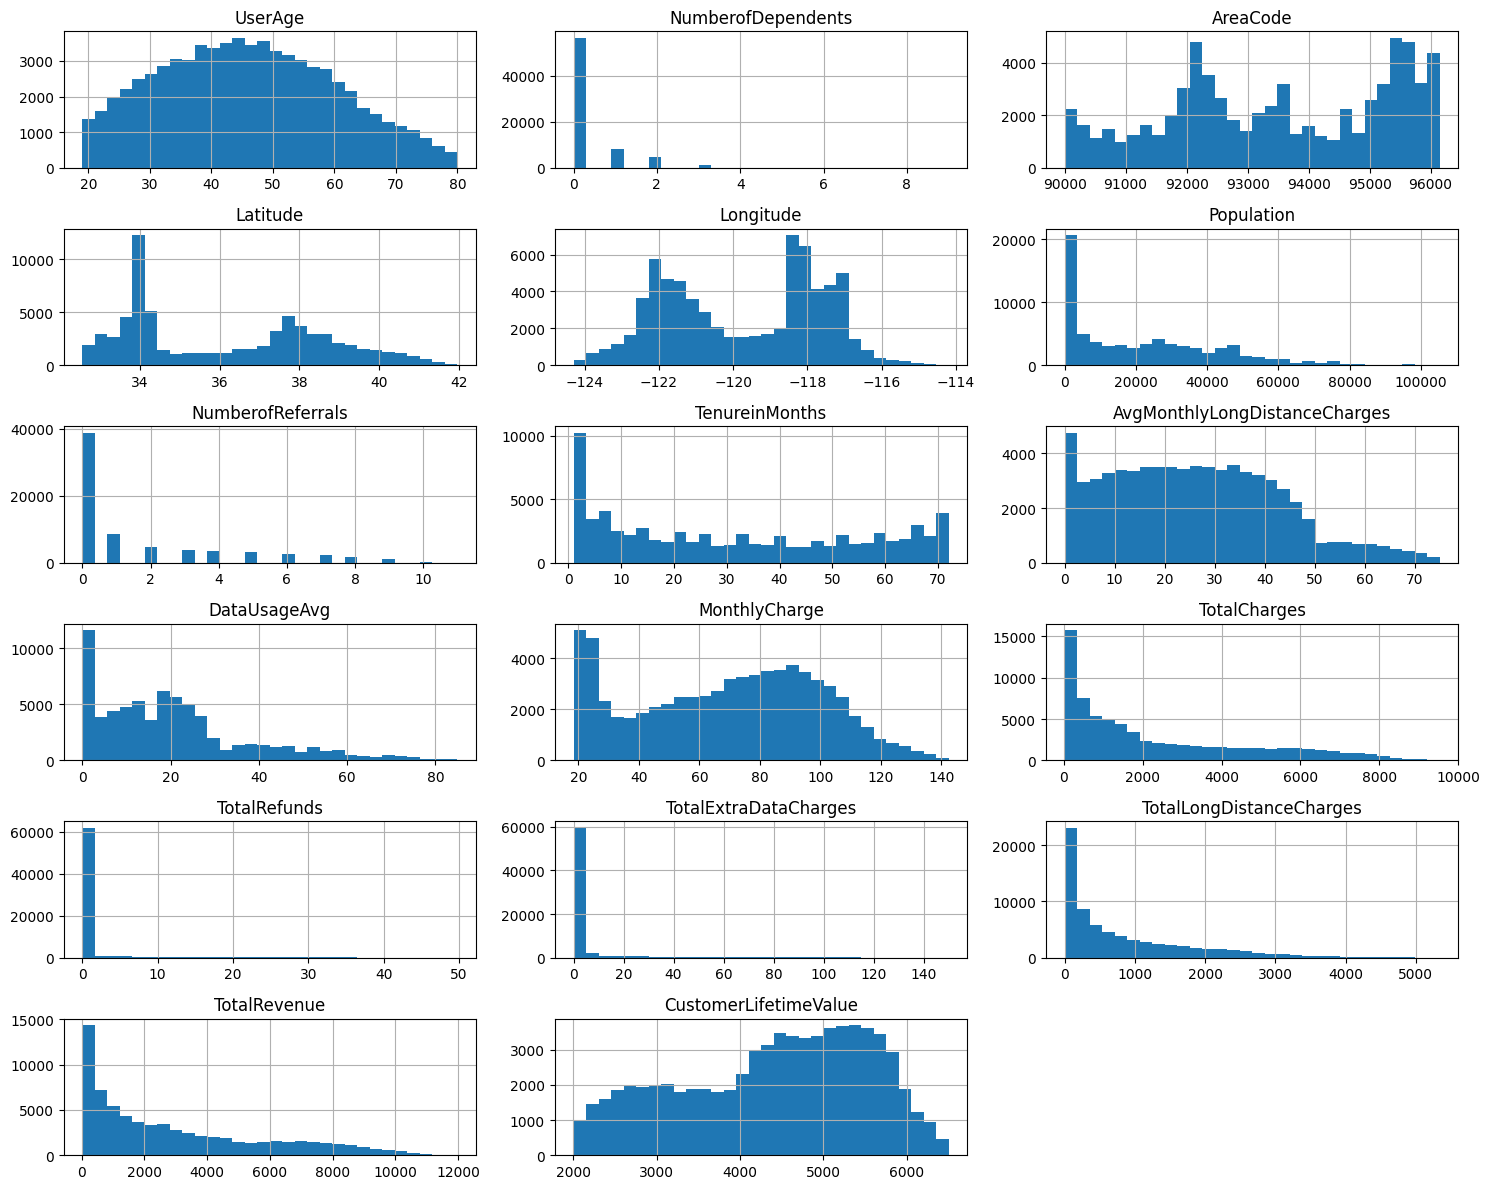

In [7]:
# Histograms for numerical features
plt.figure(figsize=(15, 10))
train_df[numerical_features].hist(bins=30, figsize=(15,12), layout=(len(numerical_features)//3 + 1, 3))
plt.tight_layout()
plt.show()

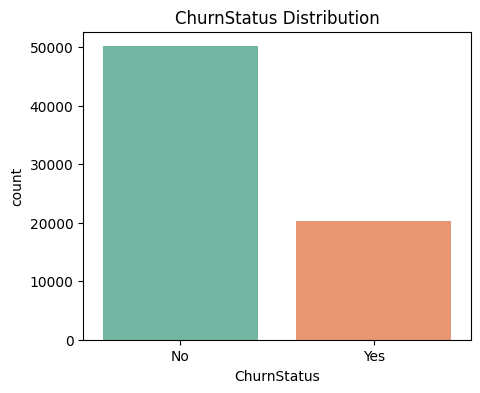

In [9]:
plt.figure(figsize=(5,4))
sns.countplot(data=train_df, x='ChurnStatus', palette='Set2')
plt.title("ChurnStatus Distribution")
plt.show()

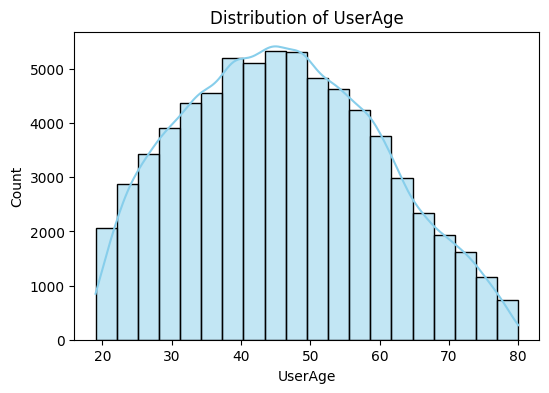

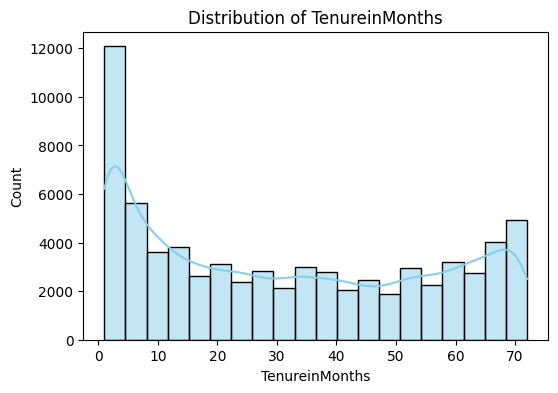

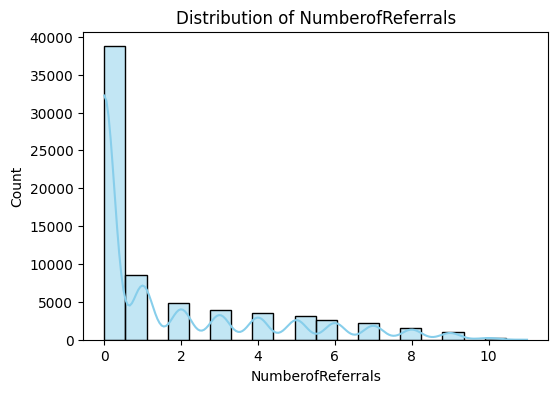

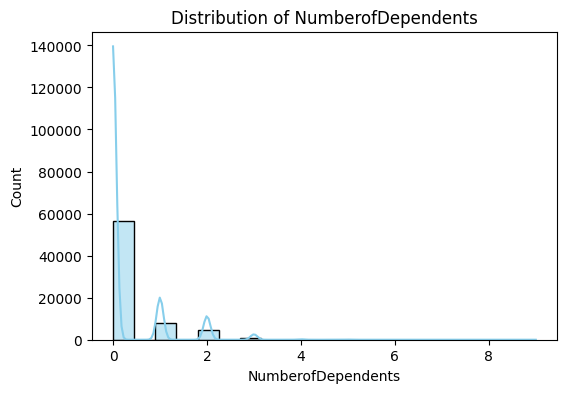

In [10]:
for col in ['UserAge', 'TenureinMonths', 'NumberofReferrals', 'NumberofDependents']:
    plt.figure(figsize=(6,4))
    sns.histplot(train_df[col], kde=True, color='skyblue', bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()


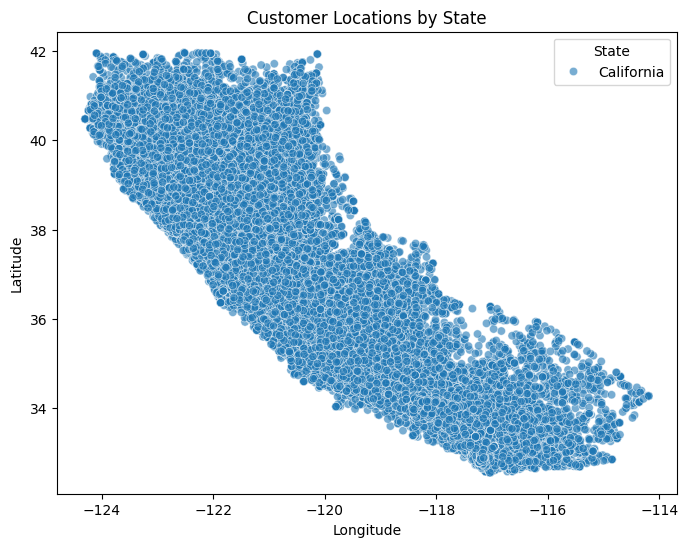

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=train_df, x='Longitude', y='Latitude', hue='State', palette='tab20', alpha=0.6)
plt.title("Customer Locations by State")
plt.show()

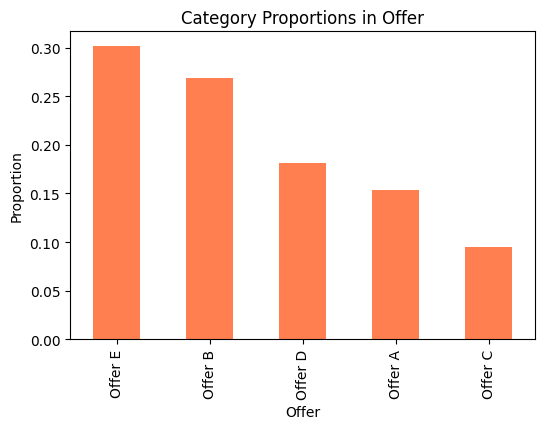

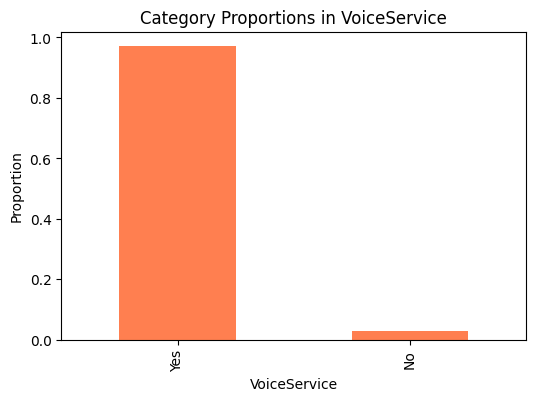

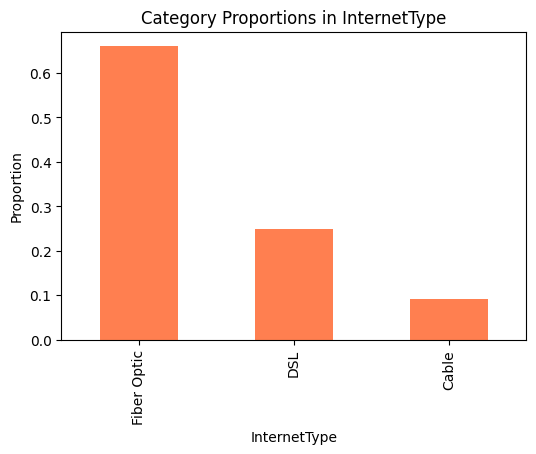

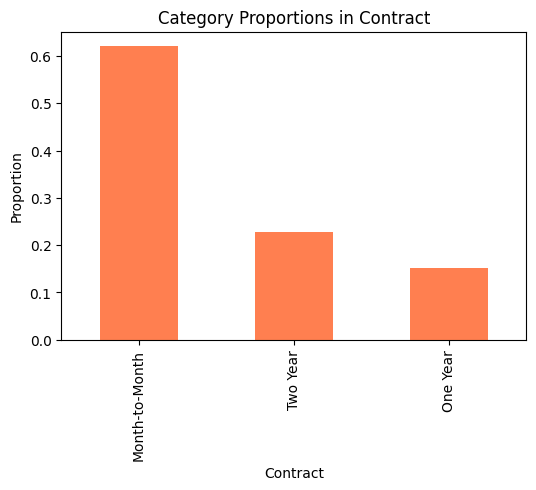

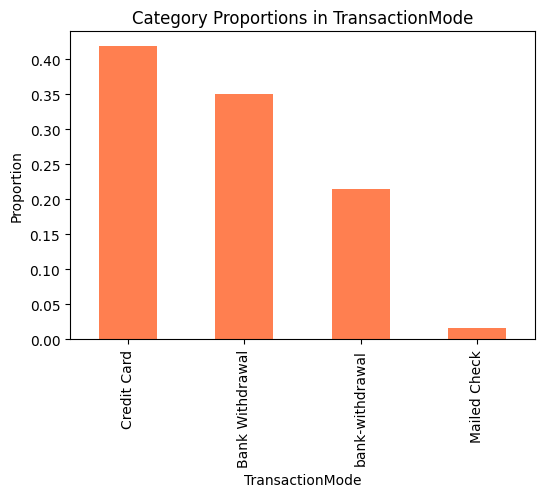

In [13]:
cat_cols = ['Offer', 'VoiceService', 'InternetType', 'Contract', 'TransactionMode']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    (train_df[col].value_counts(normalize=True)
        .plot(kind='bar', color='coral'))
    plt.title(f"Category Proportions in {col}")
    plt.ylabel("Proportion")
    plt.show()


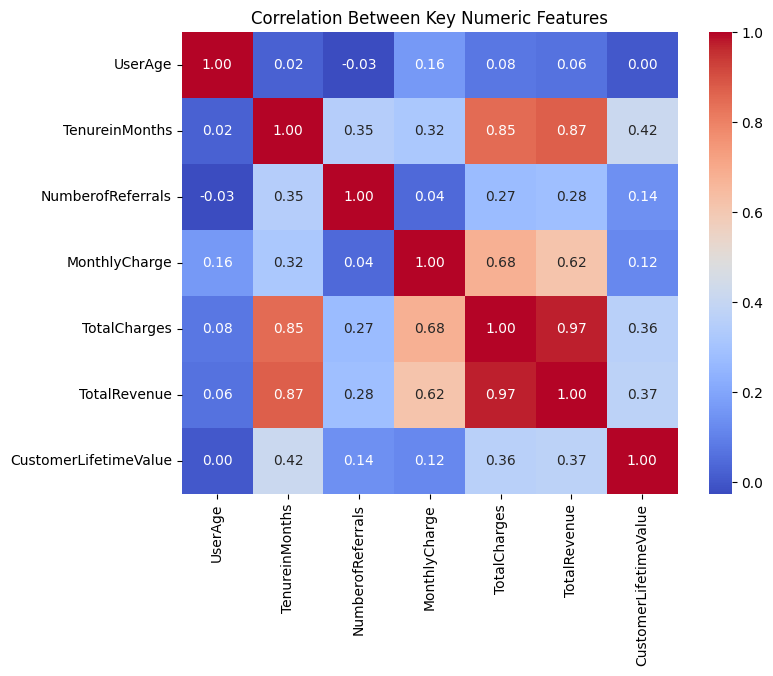

In [14]:
corr_cols = ['UserAge','TenureinMonths','NumberofReferrals','MonthlyCharge','TotalCharges','TotalRevenue','CustomerLifetimeValue']
plt.figure(figsize=(8,6))
sns.heatmap(train_df[corr_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Between Key Numeric Features")
plt.show()


In [16]:
# Convert Month to datetime (assume format like '25-Jan')
train_df['Month'] = pd.to_datetime(train_df['Month'], format='%d-%b', errors='coerce')

# Quick check
train_df[['Month']].head()


,Month
0,1900-01-25
1,1900-01-25
2,1900-01-25
3,1900-01-25
4,1900-01-25


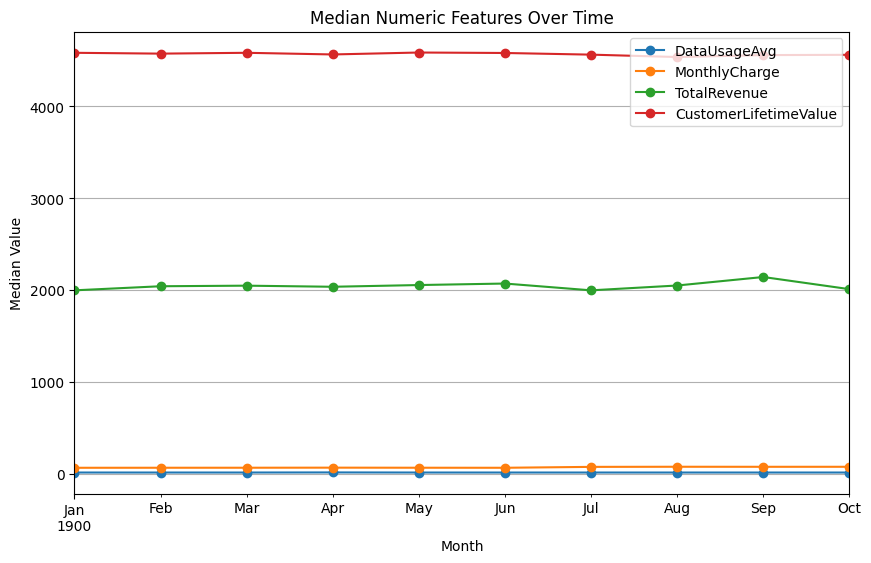

In [17]:
num_cols = ['DataUsageAvg', 'MonthlyCharge', 'TotalRevenue', 'CustomerLifetimeValue']

plt.figure(figsize=(10,6))
for col in num_cols:
    monthly_median = train_df.groupby(train_df['Month'].dt.to_period('M'))[col].median()
    monthly_median.plot(marker='o', label=col)

plt.title("Median Numeric Features Over Time")
plt.ylabel("Median Value")
plt.xlabel("Month")
plt.grid(True)
plt.legend()
plt.show()


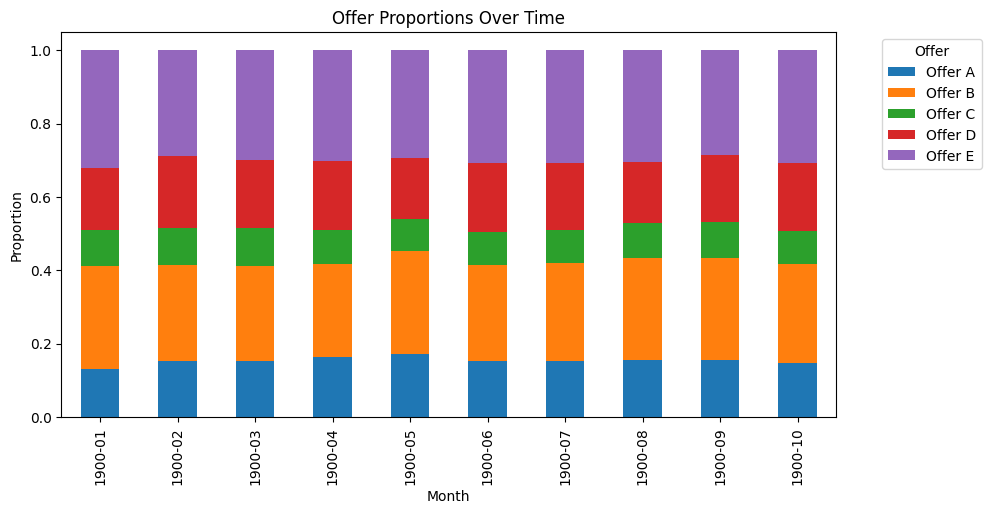

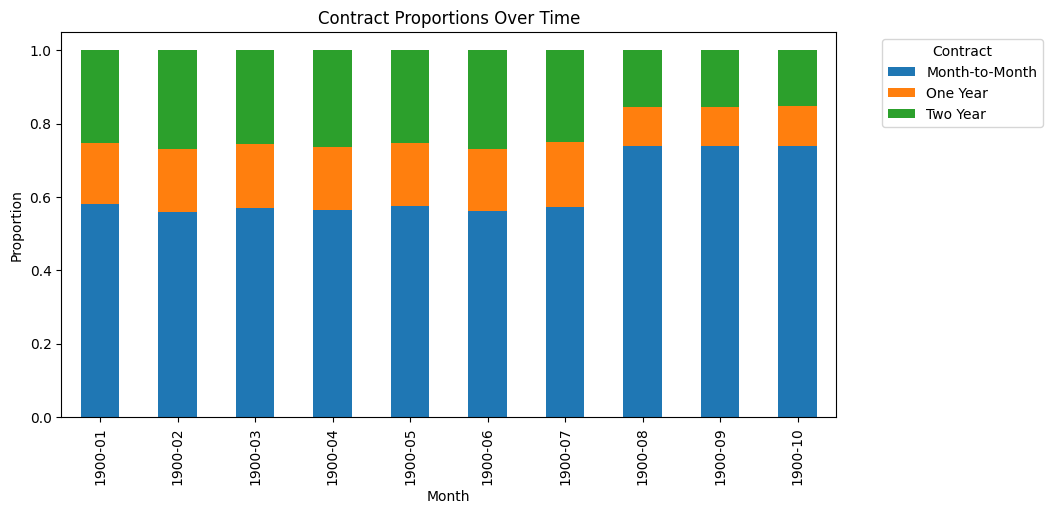

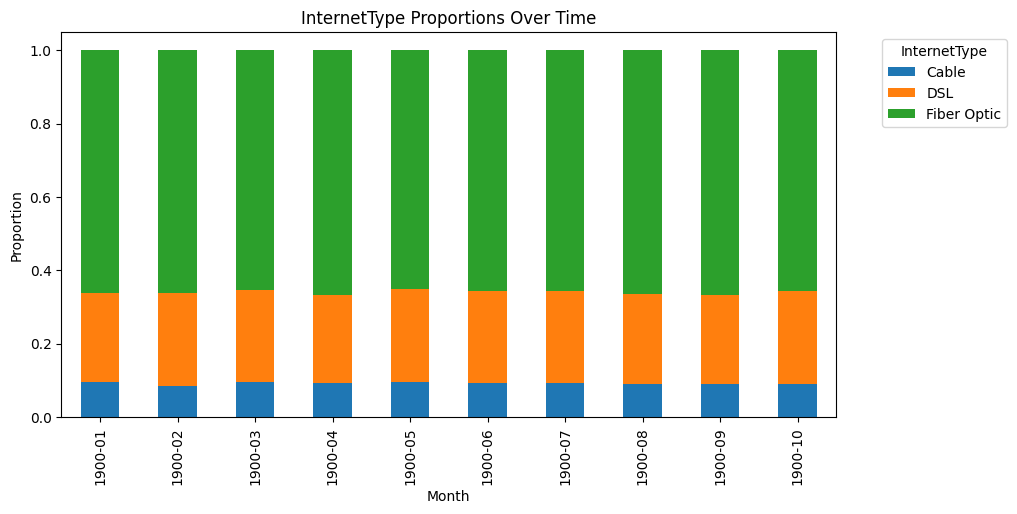

In [18]:
cat_cols = ['Offer', 'Contract', 'InternetType']

for col in cat_cols:
    prop_df = train_df.groupby(train_df['Month'].dt.to_period('M'))[col].value_counts(normalize=True).unstack()
    prop_df.plot(kind='bar', stacked=True, figsize=(10,5))
    plt.title(f"{col} Proportions Over Time")
    plt.ylabel("Proportion")
    plt.xlabel("Month")
    plt.legend(title=col, bbox_to_anchor=(1.05, 1))
    plt.show()


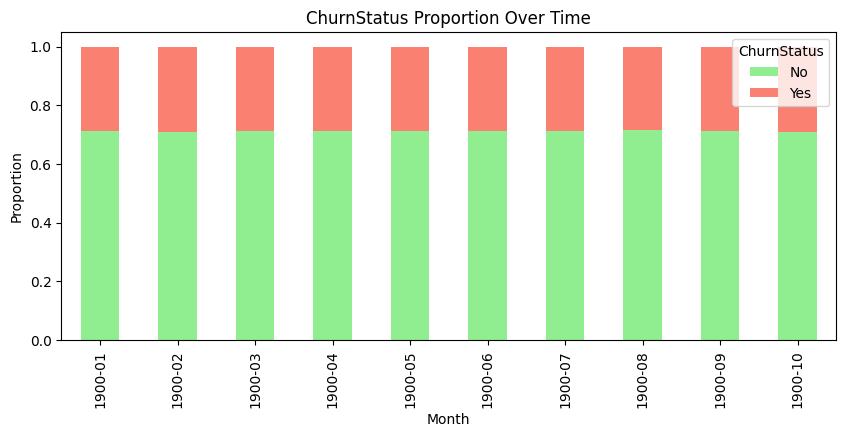

In [19]:
target_prop = train_df.groupby(train_df['Month'].dt.to_period('M'))['ChurnStatus'].value_counts(normalize=True).unstack()
target_prop.plot(kind='bar', stacked=True, figsize=(10,4), color=['lightgreen','salmon'])
plt.title("ChurnStatus Proportion Over Time")
plt.ylabel("Proportion")
plt.xlabel("Month")
plt.legend(title='ChurnStatus')
plt.show()
